# <center>Metody Numeryczne</center>

# Laboratorium 7: Pierwiastki wielomianu i wartości własne


**Wykonał:** Kacper Jasinski

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań nieliniowych. W związku z tym podczas zajęć będziemy rozważać następujący problem:

Dana jest funkcja $f(x)$. Należy wyznaczyć takie jej argumenty $x^*$, dla których zachodzi równość $f(x^*) = 0$. 

Argumenty spełniające powyższe równanie nazywane są *pierwiastkami równania*.

<br>

**Wielomian**

Dany jest wielomian $w(x)$ w postaci kanonicznej (ogólnej):

$$
w(x) = a_nx^n + a_{n-1}x^{n-1} + \ldots + a_2x^2 + a_1x + a_0
$$

jego wektor współczynników wyraża się wzorem:

$$
\mathbf{a} = (a_0, a_1, ..., a_{n-1}, a_n)
$$


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`,
    - `nppoly` - `numpy.polynomial.polynomial`.

---

In [2]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import numpy.polynomial.polynomial as nppoly

---

### **Zadanie 1.**

Dane są wielomiany w postaci iloczynowej:
$$
\begin{align*}
w_1(x) &= (x-1)(x-2)(x-3)\\
w_2(x) &= (x-1)(x-2) \cdot \ldots \cdot (x-20)
\end{align*}
$$

**Punkt 1.**

1. Oblicz wektor współczynników $\mathbf{a}_1$ wielomianu $w_1(x)$ w postaci kanonicznej dla zadanego wektora pierwiastków.

2. Sprawdź poprawność wyznaczonego wektora z definicją w sekcji **Cel zajęć**.

> **Wskazówka:** Użyj funkcji [`nppoly.polyfromroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyfromroots.html).

<br>

**Punkt 2.**

Zaimplementuj funkcję *`roots_20()`* wyznaczającą miejsca zerowe wielomianu na podstawie jego wektora współczynników. Funkcja powinna najpierw lekko zaburzać wejściowe współczynniki za pomocą dodania do nich losowej wartości postaci: $N(0,1) \cdot 1\mathrm{e}{-10}$.

> **Wskazówka:** Użyj funkcji [`np.random.random_sample()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random_sample.html) oraz [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

1. Wyznacz wektor współczynników $\mathbf{a}_2$ wielomianu $w_2(x)$.

2. W pętli 20 iteracji:
    
    1. Wyznacz pierwiastki zaburzonego wielomianu używając *`roots_20()`*.

    2. Ustaw zaburzony wektor współczynników jako nowy wektor współczynników.

    3. Wyrysuj na jednym wykresie wyznaczone części rzeczywiste pierwiastków, a na drugim części urojone (w każdej iteracji dorysowuj pierwiastki na tym samym rysunku).

4. Określ, które pierwiastki są najbardziej wrażliwe na zaburzenia oraz opisz wnioski wynikające z utworzonego wykresu.

5. Zaproponuj sposób oszacowania uwarunkowania każdego z pierwiastków.


[-6. 11. -6.  1.]
Noised poly [-6. 11. -6.  1.]
Roots [1. 2. 3.]
a2: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
poly: [ 2.43290201e+18 -8.75294804e+18  1.38037598e+19 -1.28709312e+19
  8.03781182e+18 -3.59997952e+18  1.20664780e+18 -3.11333643e+17
  6.30308121e+16 -1.01422999e+16  1.30753501e+15 -1.35585183e+14
  1.13102770e+13 -7.56111184e+11  4.01717716e+10 -1.67228082e+09
  5.33279460e+07 -1.25685000e+06  2.06150000e+04 -2.10000000e+02
  1.00000000e+00]


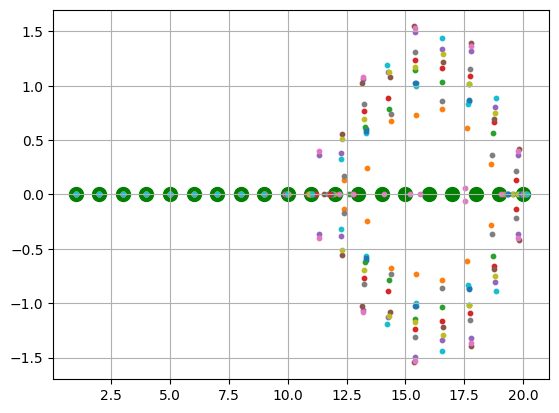

In [4]:
# ===== Twoja implementacja tutaj =====

# Punkt 1:
poly = nppoly.polyfromroots((1, 2, 3))
print(poly)

# Punkt 2:
print(f"Noised poly {main.roots_20(poly)[0]}\nRoots {main.roots_20(poly)[1]}")

# Punkt 3:
a2 = np.linspace(1, 20, 20)
print(f"a2: {a2}")
poly = nppoly.polyfromroots(a2)
print(f"poly: {poly}")


fig,ax = plt.subplots()
ax.scatter(a2.real, a2.imag, color='green', s=100)
ax.grid(True)

coef = poly.copy()

for _ in a2:
    coef_noised, roots = main.roots_20(coef)
    ax.scatter(roots.real, roots.imag, s=10)
    coef = coef_noised


Wnioski do zad 1.
W zadaniu najpierw użyliśmy funkcji nppoly.polyfromroots(), która tworzy współczynniki wielomianu na podstawie zadanych miejsc zerowych. Dzięki temu znamy dokładne miejsca zerowe i możemy później analizować, jak stabilnie są one odtwarzane numerycznie. Następnie skorzystaliśmy z funkcji roots_20(), która najpierw dodaje bardzo mały szum do współczynników wielomianu, a potem oblicza jego miejsca zerowe. Ma to na celu sprawdzenie, jak niewielkie zaburzenia danych wpływają na uzyskane miejsca zerowe, czyli analizę wrażliwości obliczeń. Na koniec wyniki przedstawiono na wykresie. Zielone punkty oznaczają prawdziwe miejsca zerowe, a pozostałe to miejsca zerowe otrzymywane po kolejnych zaburzeniach. Widać, że nawet minimalny szum powoduje duży rozrzut tych punktów, a część z nich wychodzi poza oś rzeczywistą. Pokazuje to, że wyznaczanie miejsc zerowych wielomianów wysokiego stopnia jest numerycznie niestabilne i bardzo podatne na błędy zaokrągleń.

---

### **Zadanie 2.**

Na podstawie wiedzy z wykładu wiadomo, że wartości własne macierzy kwadratowej są pierwiastkami wielomianu charakterystycznego tej macierzy oraz, że każdy wielomian posiada swoją macierz stowarzyszoną (macierz Frobeniusa). Wynika z tego, że **poszukiwanie pierwiastków wielomianu jest równoważne poszukiwaniu wartości własnych macierzy stowarzyszonej**.

<br>

Dany jest wielomian:
$$
w_3(x) = (x-1)^8
$$ 

Należy wyznaczyć numerycznie jego miejsca zerowe na różne sposoby i porównać otrzymane wyniki z wartościami analitycznymi.

**Punkt 1.**

Przygotowanie macierzy stowarzyszonej.

1. Zaiplementuj funkcję *`frob_a()`* tworzącą [macierz Frobeniusa](https://en.wikipedia.org/wiki/Companion_matrix) dla zadanego wektora współczynników wielomianu.

2. Wyznacz macierz Frobeniusa $\mathbf{F_{w_3}}$ dla wielomianu $w_3(x)$.

<br>

**Punkt 2.**

Wyznaczenie pierwiastków wielomianu.

1. Wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$ za pomocą funkcji [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html).  

2. Dokonaj rozkładu Schura macierzy $\mathbf{F_{w_3}}$ i na tej podstawie wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$. Użyj funkcji [`sp.linalg.schur()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.schur.html).

3. Wyznacz pierwiastki wielomianu $w_3(x)$ przy użyciu funkcji [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

Zestawienie wyników.

1. Utwórz wykres typu *scatter plot* i wyrysuj na nim wartości pierwiastków wyznaczonych w **Punkcie 2.** oraz pierwiastki oblicznone analitycznie na płaszczyźnie zespolonej.

2. Opisz wnioski wynikające z wykresu.

Poly:
[  1.  -8.  28. -56.  70. -56.  28.  -8.   1.]
Frobenius Matrix:
[[  0.   1.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   1.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   1.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   1.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   1.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   1.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   1.]
 [ -1.   8. -28.  56. -70.  56. -28.   8.]]


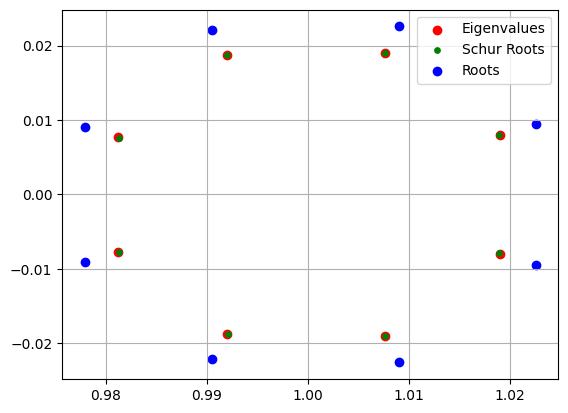

In [28]:
# ===== Twoja implementacja tutaj =====

# Punkt 1:
roots = np.linspace(1, 1, 8)

poly = nppoly.polyfromroots(roots)

frob_matrix = main.frob_a(poly)
print(f"Poly:\n{poly}")
print(f"Frobenius Matrix:\n{frob_matrix}")
# Punkt 2:
eigvals = np.linalg.eigvals(frob_matrix)

T_complex, Z_complex = sp.linalg.schur(frob_matrix, output='complex')
schur_vals = np.diag(T_complex)

roots = nppoly.polyroots(poly)

# Punkt 3:

fig, ax = plt.subplots()
ax.scatter(eigvals.real, eigvals.imag, color='red', label='Eigenvalues')
ax.scatter(schur_vals.real, schur_vals.imag, color='green', label='Schur Roots', s=15)
ax.scatter(roots.real, roots.imag, color='blue', label='Roots')

ax.legend()
ax.grid(True)

Wnioski do zad 2.
W zadaniu najpierw zdefiniowaliśmy wielomian, którego wszystkie miejsca zerowe są równe 1, czyli jest to pierwiastek o krotności 8. Następnie, korzystając z funkcji frob_a(), skonstruowaliśmy macierz Frobeniusa odpowiadającą wielomianowi charakterystycznemu. Funkcja ta tworzy macierz o strukturze jedynki na nadprzekątnej oraz ostatni wiersz zbudowany na podstawie współczynników wielomianu. Taka macierz ma dokładnie te same miejsca zerowe, co wielomian, którego współczynniki do niej podaliśmy. W kolejnym kroku wyznaczyliśmy wartości własne macierzy Frobeniusa, wykonaliśmy rozkład Schura (którego diagonalne elementy także są wartościami własnymi) oraz policzyliśmy miejsca zerowe wielomianu funkcją nppoly.polyroots(). Pozwala to porównać trzy różne numeryczne metody znajdowania tych samych wartości. Na koniec narysowaliśmy wykres przedstawiający wartości własne macierzy Frobeniusa, wartości z rozkładu Schura oraz miejsca zerowe wielomianu.

---

### **Zadanie 3.**

Dany jest wielomian:
$$
w_4(x) = 243x^7 - 486x^6 + 783x^5 - 990x^4 + 558x^3 - 28x^2 - 72x + 16
$$ 

1. Wyznacz numerycznie miejsca zerowe wielomianu $w_4(x)$ w sposób analogiczny jak w **Zadaniu 2.**

2. Wyrysuj na płaszczyźnie zespolonej wyznaczone pierwiastki oraz pierwiastki wyliczone analitycznie.

3. Porównaj otrzymane wyniki z rezulatatami otrzymanymi w **Zadaniu 2.**

>**Wskazówka:** Sprawdź poprawność wyznaczonego wektora współczynników z definicją w sekcji **Cel zajęć**.

w4 roots:
[-3.33333333e-01+0.00000000e+00j  1.46757606e-15-1.41421356e+00j
  1.46757606e-15+1.41421356e+00j  3.33333333e-01+0.00000000e+00j
  6.66660600e-01+0.00000000e+00j  6.66669700e-01-5.25437970e-06j
  6.66669700e-01+5.25437970e-06j]
w4 poly:
[ 0.06584362-1.05879118e-22j -0.2962963 +1.38777878e-17j
 -0.11522634+2.77555756e-17j  2.2962963 -1.38777878e-17j
 -4.07407407+0.00000000e+00j  3.22222222+0.00000000e+00j
 -2.        +0.00000000e+00j  1.        +0.00000000e+00j]
Frobenius Matrix:
[[ 0.          1.          0.          0.          0.          0.
   0.        ]
 [ 0.          0.          1.          0.          0.          0.
   0.        ]
 [ 0.          0.          0.          1.          0.          0.
   0.        ]
 [ 0.          0.          0.          0.          1.          0.
   0.        ]
 [ 0.          0.          0.          0.          0.          1.
   0.        ]
 [ 0.          0.          0.          0.          0.          0.
   1.        ]
 [-0.06584362  0.29

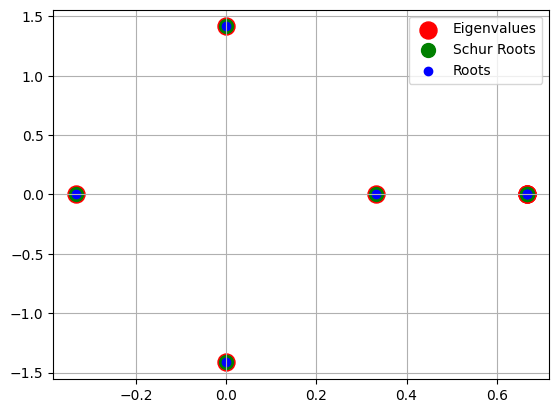

In [49]:
# ===== Twoja implementacja tutaj =====
w4 = [16, -72, -28, 558, -990, 783, -486, 243]

w4_roots = nppoly.polyroots(w4)

w4_poly = nppoly.polyfromroots(w4_roots)

w4_frob = main.frob_a(w4_poly)

print(f"w4 roots:\n{w4_roots}")
print(f"w4 poly:\n{w4_poly}")
print(f"Frobenius Matrix:\n{w4_frob}")

eigvals = np.linalg.eigvals(w4_frob)

T_complex, Z_complex = sp.linalg.schur(w4_frob, output='complex')
schur_vals = np.diag(T_complex)

fig, ax = plt.subplots()
ax.scatter(eigvals.real, eigvals.imag, color='red', label='Eigenvalues', s=150)
ax.scatter(schur_vals.real, schur_vals.imag, color='green', label='Schur Roots', s=100)
ax.scatter(w4_roots.real, w4_roots.imag, color='blue', label='Roots')

ax.legend()
ax.grid(True)


Wnioski do zad 3.
W tym zadaniu zdefiniowaliśmy listę w4, która zawiera współczynniki wielomianu w4(x). Następnie, korzystając z funkcji nppoly.polyroots(), obliczyliśmy jego miejsca zerowe. Na podstawie otrzymanych pierwiastków ponownie odtworzyliśmy wielomian funkcją polyfromroots(), a następnie wyznaczyliśmy macierz Frobeniusa odpowiadającą temu wielomianowi. Po obliczeniu wartości własnych macierzy i wartości z rozkładu Schura porównaliśmy wszystkie trzy zestawy wyników. Na końcu narysowaliśmy wykres przedstawiający miejsca zerowe wielomianu, wartości własne macierzy Frobeniusa oraz wartości z rozkładu Schura dzięki czemu widać, że wszystkie te rezultaty pokrywają się i reprezentują te same miejsca zerowe wielomianu.

---

### **Zadanie 4.**

Zadanie polega na przeanalizowaniu w jaki sposób różne przekształcenia macierzy wpływają na pojawianie się błędów numerycznych.

W celu przeprowadzenia analizy skonstruuj trzy macierze diagonalne $\mathbf{A}_n$ dla $n = \{10,20,30\}$. Współczynniki macierzy powinny być zdefiniowane jako $a_{ii} = 2^i$ dla $i = \{1,2,...,n\}$ (skorzystaj z funkcji [`np.diag()`](https://numpy.org/doc/stable/reference/generated/numpy.diag.html)).

**Punkt 1.**

1. Dla każdej z macierzy $\mathbf{A}_n$ oblicz wartości własne przy użyciu [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html) i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 2.**

1. Zdefiniuj funcję *`is_nonsingular()`* sprawdzającą czy zadana macierz nie jest singularna. 

2. Skonstruuj losowe niesingularne macierze wektorów własnych $\mathbf{P}_n$, których wartości współczynników są liczbami całkowitymi z zakresu $(0,100)$. Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{P}_n$ oblicz macierze $\mathbf{B}_n$ postaci: 
$$
\mathbf{B}_n = \mathbf{P}_n\mathbf{A}_n\mathbf{P}_{n}^{-1}
$$ 

3. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{B}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

>**Wskazówka:** Niesingularność macierzy $\mathbf{P}_n$ można zapewnić generując je w pętli, w której warunkiem stopu będzie wynik funkcji zaimplementowanej w **Podpunkcie 1.**

<br>

**Punkt 3.**

1. Bazując na macierzach $\mathbf{P}_n$ wygeneruj macierze ortogonalne $\mathbf{Q}_n$ (można do tego użyć rozkładu QR). Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{Q}_n$ oblicz macierze $\mathbf{C}_n$ postaci:
$$
\mathbf{C}_n = \mathbf{Q}_n\mathbf{A}_n\mathbf{Q}_{n}^{-1}
$$

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{C}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 4.**

1. Bazując na analitycznych wartościach własnych dla wielomianów charakterystycznych macierzy $\mathbf{A}_n$ wygeneruj macierze Frobeniusa $\mathbf{F}_n$ korzystając z funkcji zaimplementowanej w **Zadaniu 2.** 

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{F}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 5.**

Porównaj wyniki otrzymane we wszystkich punktach. Opisz z czego wynikają powstałe błędy obliczeń.

In [ ]:
# ===== Twoja implementacja tutaj =====

n = [10, 20, 30]
A_10 = np.zeros((10,10))
A_20 = np.zeros((20,20))
A_30 = np.zeros((30, 30))
def diagonal_matrix(A: np.ndarray) -> np.ndarray:
    for i in range(0, A.shape[0]):
        for j in range(0, A.shape[1]):
            if i == j:
                A[i][j] = 2 ** i
    return A
A_10 = diagonal_matrix(A_10)
A_20 = diagonal_matrix(A_20)
A_30 = diagonal_matrix(A_30)

# Punkt 1:
eig_10_num = np.linalg.eigvals(A_10)
eig_20_num = np.linalg.eigvals(A_20)    
eig_30_num = np.linalg.eigvals(A_30)

eig_10_ana = np.diag(A_10)
eig_20_ana = np.diag(A_20)
eig_30_ana = np.diag(A_30)

eig_10_diff = abs(eig_10_num - eig_10_ana)
eig_20_diff = abs(eig_20_num - eig_20_ana)
eig_30_diff = abs(eig_30_num - eig_30_ana)


# Punkt 2:
while True:
    P_10 = np.random.randint(0, 101, size=(10, 10))
    if main.is_nonsingular(P_10):
        break
while True:
    P_20 = np.random.randint(0, 101, size=(20, 20))
    if main.is_nonsingular(P_20):
        break
while True:
    P_30 = np.random.randint(0, 101, size=(30, 30))
    if main.is_nonsingular(P_30):
        break

B_10 = P_10 @ A_10 @ np.linalg.inv(P_10)
B_20 = P_20 @ A_20 @ np.linalg.inv(P_20)
B_30 = P_30 @ A_30 @ np.linalg.inv(P_30)

eig_B10_num = np.linalg.eigvals(B_10)
eig_B20_num = np.linalg.eigvals(B_20)
eig_B30_num = np.linalg.eigvals(B_30)

eig_B10_ana = np.diag(B_10)
eig_B20_ana = np.diag(B_20)
eig_B30_ana = np.diag(B_30)

eig_B10_diff = abs(eig_B10_num - eig_B10_ana)
eig_B20_diff = abs(eig_B20_num - eig_B20_ana)
eig_B30_diff = abs(eig_B30_num - eig_B30_ana)

# Punkt 3:
Q_10, R_10 = np.linalg.qr(P_10)
Q_20, R_20 = np.linalg.qr(P_20)
Q_30, R_30 = np.linalg.qr(P_30)

C_10 = Q_10 @ A_10 @ Q_10.T
C_20 = Q_20 @ A_20 @ Q_20.T
C_30 = Q_30 @ A_30 @ Q_30.T

eig_C10_num = np.linalg.eigvals(C_10)
eig_C20_num = np.linalg.eigvals(C_20)
eig_C30_num = np.linalg.eigvals(C_30)

eig_C10_ana = np.diag(A_10)
eig_C20_ana = np.diag(A_20)
eig_C30_ana = np.diag(A_30)

eig_C10_diff = abs(eig_C10_num - eig_C10_ana)
eig_C20_diff = abs(eig_C20_num - eig_C20_ana)
eig_C30_diff = abs(eig_C30_num - eig_C30_ana)

# Punkt 4:
F_10 = main.frob_a(eig_10_ana)
F_20 = main.frob_a(eig_20_ana)
F_30 = main.frob_a(eig_30_ana)

eig_F10_num = np.linalg.eigvals(F_10)
eig_F20_num = np.linalg.eigvals(F_20)
eig_F30_num = np.linalg.eigvals(F_30)

eig_F10_ana = eig_10_ana
eig_F20_ana = eig_20_ana
eig_F30_ana = eig_30_ana

eig_F10_diff = abs(eig_F10_num - eig_10_ana[1:])
eig_F20_diff = abs(eig_F20_num - eig_20_ana[1:])
eig_F30_diff = abs(eig_F30_num - eig_30_ana[1:])

# Tabela

max_error_A = [np.max(eig_10_diff), np.max(eig_20_diff), np.max(eig_30_diff)]
mean_error_A = [np.mean(eig_10_diff), np.mean(eig_20_diff), np.mean(eig_30_diff)]

max_error_B = [np.max(eig_B10_diff), np.max(eig_B20_diff), np.max(eig_B30_diff)]
mean_error_B = [np.mean(eig_B10_diff), np.mean(eig_B20_diff), np.mean(eig_B30_diff)]

max_error_C = [np.max(eig_C10_diff), np.max(eig_C20_diff), np.max(eig_C30_diff)]
mean_error_C = [np.mean(eig_C10_diff), np.mean(eig_C20_diff), np.mean(eig_C30_diff)]

max_error_F = [np.max(eig_F10_diff), np.max(eig_F20_diff), np.max(eig_F30_diff)]
mean_error_F = [np.mean(eig_F10_diff), np.mean(eig_F20_diff), np.mean(eig_F30_diff)]

n_values = [10, 20, 30]
for i, n in enumerate(n_values):
    print(f"   {'Macierz':<18} {'Błąd maksymalny':<18} {'Błąd średni':<18}")
    print(f"   {'-'*55}")
    print(f"   {'A_' + str(n) + ' (diag)':<18} {max_error_A[i]:<18.2e} {mean_error_A[i]:<18.2e}")
    print(f"   {'B_' + str(n) + ' (P*A*P^-1)':<18} {max_error_B[i]:<18.2e} {mean_error_B[i]:<18.2e}")
    print(f"   {'C_' + str(n) + ' (Q*A*Q^T)':<18} {max_error_C[i]:<18.2e} {mean_error_C[i]:<18.2e}")
    print(f"   {'F_' + str(n) + ' (Frobenius)':<18} {max_error_F[i]:<18.2e} {mean_error_F[i]:<18.2e}\n")

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_10 (diag)        0.00e+00           0.00e+00          
   B_10 (P*A*P^-1)    2.07e+03           9.42e+02          
   C_10 (Q*A*Q^T)     5.11e+02           1.92e+02          
   F_10 (Frobenius)   5.12e+02           1.14e+02          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_20 (diag)        0.00e+00           0.00e+00          
   B_20 (P*A*P^-1)    2.52e+06           8.41e+05          
   C_20 (Q*A*Q^T)     5.24e+05           1.05e+05          
   F_20 (Frobenius)   5.24e+05           5.52e+04          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_30 (diag)        0.00e+00           0.00e+00          
   B_30 (P*A*P^-1)    7.89e+08           2.96e+08          
   C_30 (Q*A*Q^T)     5.37e+08           

Wnioski do zad 4.
W zadaniu skonstruowaliśmy trzy macierze diagonalne o rozmiarach 10, 20 i 30, w których elementy diagonalne mają postać 2^i. Dzięki temu znamy ich miejsca zerowe w sposób analityczny i możemy porównać je z wynikami obliczeń numerycznych. Najpierw wyznaczyliśmy wartości własne macierzy diagonalnych bez żadnych przekształceń, a następnie sprawdziliśmy, jak zmieniają się błędy przy kolejnych modyfikacjach macierzy. W drugim etapie wykonaliśmy podobieństwowe przekształcenie B=PAP^(−1) z użyciem losowych, odwracalnych macierzy P. Choć takie przekształcenie nie powinno zmieniać wartości własnych, pojawiają się drobne błędy numeryczne wynikające z odwracania i mnożenia macierzy. W punkcie trzecim wykorzystaliśmy rozkład QR do utworzenia macierzy ortogonalnej Q i wyznaczyliśmy macierze C=QAQ. Transformacje ortogonalne są znacznie bardziej stabilne numerycznie, dlatego błędy wartości własnych są tu mniejsze niż w przypadku macierzy B. W ostatnim punkcie skonstruowaliśmy macierze Frobeniusa dla trzech zestawów wartości własnych i ponownie obliczyliśmy ich miejsca zerowe. Macierze Frobeniusa są bardzo wrażliwe na błędy zaokrągleń, dlatego odchylenia miejsc zerowych są wyraźnie większe, zwłaszcza dla większych wymiarów macierzy. Na koniec wszystkie wyniki zebrano w tabeli, która porównuje maksymalne i średnie błędy wyznaczonych wartości własnych dla macierzy diagonalnych, przekształceń podobieństwowych, przekształceń ortogonalnych oraz macierzy Frobeniusa. Pokazuje to, że stabilność obliczeniowa znacząco zależy od rodzaju stosowanego przekształcenia.

**Przykładowa forma zestawienia wyników:**
```python
for i, n in enumerate(n_values):
    print(f"   {'Macierz':<18} {'Błąd maksymalny':<18} {'Błąd średni':<18}")
    print(f"   {'-'*55}")
    print(f"   {'A_' + str(n) + ' (diag)':<18} {max_error_A[i]:<18.2e} {mean_error_A[i]:<18.2e}")
    print(f"   {'B_' + str(n) + ' (P*A*P^-1)':<18} {max_error_B[i]:<18.2e} {mean_error_B[i]:<18.2e}")
    print(f"   {'C_' + str(n) + ' (Q*A*Q^T)':<18} {max_error_C[i]:<18.2e} {mean_error_C[i]:<18.2e}")
    print(f"   {'F_' + str(n) + ' (Frobenius)':<18} {max_error_F[i]:<18.2e} {mean_error_F[i]:<18.2e}\n")
```

**Rezultat:**
```md
   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_10 (diag)        0.00e+00           0.00e+00          
   B_10 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_10 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_10 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_20 (diag)        0.00e+00           0.00e+00          
   B_20 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_20 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_20 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_30 (diag)        0.00e+00           0.00e+00          
   B_30 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_30 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_30 (Frobenius)   0.00e+00           0.00e+00
```

---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)